In [17]:
import pandas as pd
df = pd.read_csv('../data/loan_raw.csv.gz')
print(df.shape)

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\2687718265.py:2: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/loan_raw.csv.gz')


(2260701, 151)


In [18]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [19]:
default_statuses = ['Charged Off', 'Does not meet the credit policy. Status:Charged Off']
paid_statuses = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']

df_clean = df[df['loan_status'].isin(default_statuses + paid_statuses)].copy()
df_clean['default'] = df_clean['loan_status'].isin(default_statuses).astype(int)

print(df_clean.shape)
df_clean['default'].value_counts()

(1348059, 152)


default
0    1078739
1     269320
Name: count, dtype: int64

In [20]:
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary.shape[0], "columns have missing values")
missing_summary.head(30)

113 columns have missing values


,missing_count,missing_pct
member_id,1348059,100.00
next_pymnt_d,1345310,99.80
orig_projected_additional_accrued_interest,1344300,99.72
hardship_loan_status,1342305,99.57
hardship_dpd,1342305,99.57
hardship_start_date,1342305,99.57
hardship_end_date,1342305,99.57
hardship_status,1342305,99.57
hardship_type,1342305,99.57
hardship_amount,1342305,99.57


In [21]:
threshold = 40  # drop columns missing more than 40%
cols_to_drop = missing_summary[missing_summary['missing_pct'] > threshold].index.tolist()
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns")
print(df_clean.shape)

Dropped 58 columns
(1348059, 94)


In [22]:
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
remaining_pct = (remaining_missing / len(df_clean) * 100).round(2)
pd.DataFrame({'missing_count': remaining_missing, 'missing_pct': remaining_pct})

,missing_count,missing_pct
mths_since_recent_inq,176820,13.12
num_tl_120dpd_2m,120150,8.91
mo_sin_old_il_acct,108324,8.04
emp_title,85944,6.38
emp_length,78545,5.83
pct_tl_nvr_dlq,70430,5.22
avg_cur_bal,70298,5.21
num_rev_accts,70277,5.21
mo_sin_old_rev_tl_op,70277,5.21
mo_sin_rcnt_rev_tl_op,70277,5.21


In [23]:
# Group 1: drop low-value text columns
df_clean = df_clean.drop(columns=['emp_title', 'title'])

# Group 2: median imputation for numeric columns
numeric_impute_cols = ['mths_since_recent_inq','num_tl_120dpd_2m','mo_sin_old_il_acct',
    'pct_tl_nvr_dlq','avg_cur_bal','num_rev_accts','mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl','num_tl_90g_dpd_24m','num_tl_30dpd','num_bc_tl','num_il_tl','num_actv_rev_tl',
    'num_accts_ever_120_pd','num_actv_bc_tl','num_rev_tl_bal_gt_0','total_rev_hi_lim','tot_cur_bal',
    'tot_coll_amt','total_il_high_credit_limit','num_tl_op_past_12m','tot_hi_cred_lim','num_op_rev_tl',
    'bc_util','percent_bc_gt_75','bc_open_to_buy','mths_since_recent_bc','num_bc_sats','num_sats',
    'total_bal_ex_mort','mort_acc','total_bc_limit','acc_open_past_24mths']
for col in numeric_impute_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Group 3: mode imputation for emp_length
df_clean['emp_length'] = df_clean['emp_length'].fillna(df_clean['emp_length'].mode()[0])

# Group 4: drop rows with remaining tiny missingness
df_clean = df_clean.dropna()

print(df_clean.shape)
print(df_clean.isnull().sum().sum(), "total missing values left")

(1343086, 92)
0 total missing values left


In [24]:
print(df_clean.shape)
print(df_clean.isnull().sum().sum())

(1343086, 92)
0


In [25]:
df_clean.to_pickle('../data/cleaned_loans.pkl')

In [26]:
'dti' in df_clean.columns

True

In [27]:
print(df_clean['dti'].describe())

count    1.343086e+06
mean     1.828518e+01
std      1.115266e+01
min     -1.000000e+00
25%      1.180000e+01
50%      1.762000e+01
75%      2.405000e+01
max      9.990000e+02
Name: dti, dtype: float64


In [28]:
print((df_clean['dti'] < 0).sum())
print((df_clean['dti'] > 100).sum())

2
531


In [29]:
before = df_clean.shape[0]
df_clean = df_clean[(df_clean['dti'] >= 0) & (df_clean['dti'] <= 100)]
after = df_clean.shape[0]
print(f"Dropped {before - after} rows. New shape: {df_clean.shape}")

Dropped 533 rows. New shape: (1342553, 92)


In [30]:
print(df_clean[['issue_d', 'earliest_cr_line']].head())
print(df_clean['issue_d'].dtype)

    issue_d earliest_cr_line
0  Dec-2015         Aug-2003
1  Dec-2015         Dec-1999
2  Dec-2015         Aug-2000
4  Dec-2015         Jun-1998
5  Dec-2015         Oct-1987
object


In [31]:
df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y')
df_clean['earliest_cr_line'] = pd.to_datetime(df_clean['earliest_cr_line'], format='%b-%Y')

In [32]:
df_clean['credit_hist_length_months'] = (
    (df_clean['issue_d'] - df_clean['earliest_cr_line']).dt.days / 30.44
).round(0).astype(int)

print(df_clean['credit_hist_length_months'].describe())

count    1.342553e+06
mean     1.950990e+02
std      9.007208e+01
min      1.200000e+01
25%      1.350000e+02
50%      1.770000e+02
75%      2.400000e+02
max      9.990000e+02
Name: credit_hist_length_months, dtype: float64


In [33]:
print((df_clean['credit_hist_length_months'] >= 900).sum())

1


In [34]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean['credit_hist_length_months'] < 900]
after = df_clean.shape[0]
print(f"Dropped {before - after} row. New shape: {df_clean.shape}")

print(df_clean['credit_hist_length_months'].describe())

Dropped 1 row. New shape: (1342552, 93)
count    1.342552e+06
mean     1.950984e+02
std      9.006944e+01
min      1.200000e+01
25%      1.350000e+02
50%      1.770000e+02
75%      2.400000e+02
max      8.520000e+02
Name: credit_hist_length_months, dtype: float64


In [35]:
from sklearn.model_selection import train_test_split

feature_cols = ['dti', 'credit_hist_length_months']  # we'll expand this list shortly
X = df_clean[feature_cols]
y = df_clean['default']  # adjust if your target column has a different name

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(1074041, 2) (268511, 2)
default
0    0.801667
1    0.198333
Name: proportion, dtype: float64


In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(X_train_balanced.shape)
print(y_train_balanced.value_counts(normalize=True))

(1722046, 2)
default
0    0.5
1    0.5
Name: proportion, dtype: float64


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

AUC: 0.5824115085888375
Accuracy: 0.570289485346969
              precision    recall  f1-score   support

           0       0.84      0.58      0.68    215256
           1       0.24      0.54      0.33     53255

    accuracy                           0.57    268511
   macro avg       0.54      0.56      0.51    268511
weighted avg       0.72      0.57      0.61    268511



In [38]:
print(df_clean[['int_rate', 'annual_inc', 'loan_amnt']].describe())

           int_rate    annual_inc     loan_amnt
count  1.342552e+06  1.342552e+06  1.342552e+06
mean   1.323408e+01  7.628578e+04  1.441186e+04
std    4.760988e+00  6.986960e+04  8.709939e+03
min    5.310000e+00  4.300000e+02  5.000000e+02
25%    9.750000e+00  4.600000e+04  8.000000e+03
50%    1.274000e+01  6.500000e+04  1.200000e+04
75%    1.599000e+01  9.000000e+04  2.000000e+04
max    3.099000e+01  1.099920e+07  4.000000e+04


In [39]:
print((df_clean['annual_inc'] > 500000).sum())
print((df_clean['annual_inc'] > 1000000).sum())
import numpy as np
df_clean['log_annual_inc'] = np.log1p(df_clean['annual_inc'])
print(df_clean['log_annual_inc'].describe())

1742
287
count    1.342552e+06
mean     1.108587e+01
std      5.374687e-01
min      6.066108e+00
25%      1.073642e+01
50%      1.108216e+01
75%      1.140758e+01
max      1.621333e+01
Name: log_annual_inc, dtype: float64


In [40]:
feature_cols = ['dti', 'credit_hist_length_months', 'int_rate', 'log_annual_inc', 'loan_amnt']
X = df_clean[feature_cols]
y = df_clean['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

AUC: 0.6897908285491663
Accuracy: 0.6506325625393373
              precision    recall  f1-score   support

           0       0.87      0.66      0.75    215256
           1       0.31      0.61      0.41     53255

    accuracy                           0.65    268511
   macro avg       0.59      0.63      0.58    268511
weighted avg       0.76      0.65      0.68    268511



In [41]:
df_clean.to_pickle('../data/cleaned_loans.pkl')  # overwrite with new features included

In [42]:
import numpy as np
import pandas as pd

def calculate_woe_iv(df, feature, target, bins=10):
    data = df[[feature, target]].copy()
    data['bin'] = pd.qcut(data[feature], q=bins, duplicates='drop')

    grouped = data.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad

    # tiny epsilon avoids divide-by-zero if a bin has 0 goods or 0 bads
    eps = 1e-6
    grouped['woe'] = np.log((grouped['good_pct'] + eps) / (grouped['bad_pct'] + eps))
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']

    total_iv = grouped['iv'].sum()
    return grouped, total_iv

In [43]:
for col in ['dti', 'credit_hist_length_months']:
    woe_table, iv_value = calculate_woe_iv(df_clean, col, 'default', bins=10)
    print(f"\n=== {col} | Total IV = {iv_value:.4f} ===")
    print(woe_table[['total', 'good', 'bad', 'woe', 'iv']])

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])



=== dti | Total IV = 0.0740 ===
                  total    good    bad       woe        iv
bin                                                       
(-0.001, 7.28]   134466  115141  19325  0.388011  0.013349
(7.28, 10.49]    134140  113836  20304  0.327194  0.009657
(10.49, 13.02]   134442  112768  21674  0.252474  0.005902
(13.02, 15.324]  133973  110939  23034  0.175264  0.002904
(15.324, 17.61]  134306  109606  24700  0.093345  0.000847
(17.61, 19.98]   134549  108172  26377  0.014487  0.000021
(19.98, 22.59]   134185  106032  28153 -0.070655  0.000510
(22.59, 25.68]   134449  103906  30543 -0.172390  0.003131
(25.68, 29.76]   134079  100598  33481 -0.296586  0.009571
(29.76, 100.0]   133963   95281  38682 -0.495282  0.028104

=== credit_hist_length_months | Total IV = 0.0094 ===
                 total    good    bad       woe        iv
bin                                                      
(11.999, 97.0]  134857  105100  29757 -0.134894  0.001902
(97.0, 125.0]   135099  105818

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])


In [44]:
for col in ['int_rate', 'log_annual_inc', 'loan_amnt']:
    woe_table, iv_value = calculate_woe_iv(df_clean, col, 'default', bins=10)
    print(f"\n=== {col} | Total IV = {iv_value:.4f} ===")
    print(woe_table[['total', 'good', 'bad', 'woe', 'iv']])

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])



=== int_rate | Total IV = 0.4493 ===
                            total    good    bad       woe        iv
bin                                                                 
(5.308999999999999, 7.39]  135269  128722   6547  1.581873  0.150296
(7.39, 8.9]                135680  124223  11457  0.986720  0.071430
(8.9, 10.49]               137420  120856  16564  0.590618  0.029580
(10.49, 11.53]             134639  113909  20730  0.307072  0.008593
(11.53, 12.74]             131994  109397  22597  0.180421  0.003027
(12.74, 13.98]             131818  105320  26498 -0.016809  0.000028
(13.98, 15.22]             134427  103188  31239 -0.201856  0.004329
(15.22, 16.99]             138592  101623  36969 -0.385549  0.017125
(16.99, 19.47]             128489   87959  40530 -0.621909  0.043837
(19.47, 30.99]             134224   81082  53142 -0.974241  0.121041


C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])



=== log_annual_inc | Total IV = 0.0294 ===
                               total    good    bad       woe        iv
bin                                                                    
(6.0649999999999995, 10.434]  134692  102535  32157 -0.237167  0.006048
(10.434, 10.645]              139057  107375  31682 -0.176163  0.003386
(10.645, 10.82]               157713  123329  34384 -0.119478  0.001737
(10.82, 10.951]               110321   87109  23212 -0.074251  0.000463
(10.951, 11.082]              154995  122909  32086 -0.053718  0.000339
(11.082, 11.212]              109888   88454  21434  0.020761  0.000035
(11.212, 11.35]               152333  123504  28829  0.058148  0.000377
(11.35, 11.513]               133923  110349  23574  0.146759  0.002054
(11.513, 11.736]              118013   98758  19255  0.238156  0.004631
(11.736, 16.213]              131617  111957  19660  0.342782  0.010348

=== loan_amnt | Total IV = 0.0351 ===
                     total    good    bad       woe  

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])


In [45]:
def apply_woe(df, feature, woe_table):
    bins = woe_table.index
    woe_map = {b: woe_table.loc[b, 'woe'] for b in bins}
    binned = pd.cut(df[feature], bins=[b.left for b in bins] + [bins[-1].right], include_lowest=True)
    return binned.map(lambda b: woe_map.get(b, 0))

scorecard_features = ['int_rate', 'dti', 'loan_amnt', 'log_annual_inc']  # dropped credit_hist_length_months (IV < 0.02)

woe_tables = {}
for col in scorecard_features:
    woe_tables[col], _ = calculate_woe_iv(df_clean, col, 'default', bins=10)
    df_clean[col + '_woe'] = apply_woe(df_clean, col, woe_tables[col])

print(df_clean[[c + '_woe' for c in scorecard_features]].describe())

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

       log_annual_inc_woe
count        1.342552e+06
mean         3.743320e-02
std          1.550187e-01
min         -1.761626e-01
25%         -7.425120e-02
50%          2.076104e-02
75%          1.467592e-01
max          3.427819e-01


In [46]:
pip install xgboost


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ----------------

In [48]:
def apply_woe(df, feature, woe_table):
    bins = woe_table.index
    woe_map = {b: woe_table.loc[b, 'woe'] for b in bins}
    binned = pd.cut(df[feature], bins=[b.left for b in bins] + [bins[-1].right], include_lowest=True)
    return binned.map(lambda b: woe_map.get(b, 0)).astype(float)

In [49]:
def apply_woe(df, feature, woe_table):
    bins = woe_table.index
    woe_map = {b: woe_table.loc[b, 'woe'] for b in bins}
    binned = pd.cut(df[feature], bins=[b.left for b in bins] + [bins[-1].right], include_lowest=True)
    return binned.map(lambda b: woe_map.get(b, 0))

scorecard_features = ['int_rate', 'dti', 'loan_amnt', 'log_annual_inc']  # dropped credit_hist_length_months (IV < 0.02)

woe_tables = {}
for col in scorecard_features:
    woe_tables[col], _ = calculate_woe_iv(df_clean, col, 'default', bins=10)
    df_clean[col + '_woe'] = apply_woe(df_clean, col, woe_tables[col])

print(df_clean[[c + '_woe' for c in scorecard_features]].describe())

C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

       log_annual_inc_woe
count        1.342552e+06
mean         3.743320e-02
std          1.550187e-01
min         -1.761626e-01
25%         -7.425120e-02
50%          2.076104e-02
75%          1.467592e-01
max          3.427819e-01


C:\Users\91703\AppData\Local\Temp\ipykernel_19676\3590051166.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bin')[target].agg(['count', 'sum'])


In [51]:
print(df_clean[woe_cols].dtypes)

int_rate_woe          category
dti_woe               category
loan_amnt_woe         category
log_annual_inc_woe     float64
dtype: object


In [52]:
woe_cols = [c + '_woe' for c in scorecard_features]
df_clean[woe_cols] = df_clean[woe_cols].astype(float)   # <-- new line, forces all 4 to plain floats
X = df_clean[woe_cols]
y = df_clean['default']

In [53]:
print(df_clean[woe_cols].dtypes)

int_rate_woe          float64
dti_woe               float64
loan_amnt_woe         float64
log_annual_inc_woe    float64
dtype: object


In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

woe_cols = [c + '_woe' for c in scorecard_features]
X = df_clean[woe_cols]
y = df_clean['default']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_scores = cross_val_score(log_model, X, y, cv=cv, scoring='roc_auc')

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100, max_depth=4)
xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')

print("Logistic Regression AUC per fold:", log_scores.round(4))
print(f"Logistic Regression: mean AUC = {log_scores.mean():.4f} (+/- {log_scores.std():.4f})")
print()
print("XGBoost AUC per fold:", xgb_scores.round(4))
print(f"XGBoost: mean AUC = {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

Logistic Regression AUC per fold: [0.6665 0.6683 0.6701 0.6688 0.6681]
Logistic Regression: mean AUC = 0.6684 (+/- 0.0012)

XGBoost AUC per fold: [0.6922 0.6932 0.6948 0.6935 0.6942]
XGBoost: mean AUC = 0.6936 (+/- 0.0009)


In [55]:
required_cols = ['funded_amnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']
print([c for c in required_cols if c in df_clean.columns])
print([c for c in required_cols if c not in df_clean.columns])

['funded_amnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']
[]


In [56]:
defaults = df_clean[df_clean['default'] == 1].copy()

defaults['EAD'] = defaults['funded_amnt'] - defaults['total_rec_prncp']
defaults['net_recovery'] = defaults['recoveries'] - defaults['collection_recovery_fee']

# Guard against divide-by-zero: if EAD is 0 (fully repaid principal before charge-off), LGD is undefined
defaults['LGD'] = np.where(
    defaults['EAD'] > 0,
    1 - (defaults['net_recovery'] / defaults['EAD']),
    np.nan
)

# LGD can't go below 0% (recovered more than owed) or above 100% (impossible) in a clean calc — clip it
defaults['LGD'] = defaults['LGD'].clip(0, 1)

print(defaults[['funded_amnt', 'total_rec_prncp', 'EAD', 'recoveries', 'collection_recovery_fee', 'net_recovery', 'LGD']].describe())

         funded_amnt  total_rec_prncp            EAD     recoveries  \
count  266273.000000    266273.000000  266273.000000  266273.000000   
mean    15548.070965      4424.544727   11123.526238    1206.701455   
std      8791.382820      4119.476056    7724.733109    1840.074402   
min       600.000000         0.000000       0.000000       0.000000   
25%      9000.000000      1558.750000    4993.470000       0.000000   
50%     14300.000000      3192.010000    9467.210000     591.050000   
75%     20400.000000      5933.020000   15521.800000    1720.760000   
max     40000.000000     39989.790000   40000.000000   39859.550000   

       collection_recovery_fee   net_recovery            LGD  
count            266273.000000  266273.000000  266251.000000  
mean                201.321213    1005.380241       0.908608  
std                 329.110576    1525.332670       0.110544  
min                   0.000000       0.000000       0.000000  
25%                   0.000000       0.000000

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb_final = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100, max_depth=4)
xgb_final.fit(X_train, y_train)

pd_test = xgb_final.predict_proba(X_test)[:, 1]
portfolio_lgd = defaults['LGD'].mean()
ead_test = df_clean.loc[X_test.index, 'funded_amnt']

expected_loss = pd_test * portfolio_lgd * ead_test

print(f"Average LGD used: {portfolio_lgd:.4f}")
print(f"Total exposure (EAD) in test set: ₹{ead_test.sum():,.0f}")
print(f"Total Expected Loss: ₹{expected_loss.sum():,.0f}")
print(f"Expected Loss as % of exposure: {expected_loss.sum() / ead_test.sum() * 100:.2f}%")

Average LGD used: 0.9086
Total exposure (EAD) in test set: ₹3,866,214,600
Total Expected Loss: ₹748,786,865
Expected Loss as % of exposure: 19.37%


In [59]:
from scipy.stats import ks_2samp

pd_defaults = pd_test[y_test.values == 1]
pd_nondefaults = pd_test[y_test.values == 0]

ks_stat, ks_pvalue = ks_2samp(pd_defaults, pd_nondefaults)
print(f"KS statistic: {ks_stat:.4f}")
print(f"As a 0-100 scale (industry convention): {ks_stat*100:.1f}")

KS statistic: 0.2754
As a 0-100 scale (industry convention): 27.5


In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='roc_auc')

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6, n_jobs=-1)
rf_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print(f"Decision Tree: mean AUC = {dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")
print(f"Random Forest: mean AUC = {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

Decision Tree: mean AUC = 0.6870 (+/- 0.0012)
Random Forest: mean AUC = 0.6901 (+/- 0.0012)


In [61]:
# Standard scorecard scaling choices (industry-typical values)
base_score = 600
base_odds = 50      # 50:1 good:bad odds at the base score
pdo = 20             # points to double the odds

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

print(f"Factor: {factor:.4f}")
print(f"Offset: {offset:.4f}")

scorecard_points = {}
for col in scorecard_features:
    woe_tab = woe_tables[col]
    points = -(woe_tab['woe'] * factor).round(0).astype(int)
    scorecard_points[col] = points
    print(f"\n=== {col} points by bin ===")
    print(points)

Factor: 28.8539
Offset: 487.1229

=== int_rate points by bin ===
bin
(5.308999999999999, 7.39]   -46
(7.39, 8.9]                 -28
(8.9, 10.49]                -17
(10.49, 11.53]               -9
(11.53, 12.74]               -5
(12.74, 13.98]                0
(13.98, 15.22]                6
(15.22, 16.99]               11
(16.99, 19.47]               18
(19.47, 30.99]               28
Name: woe, dtype: int64

=== dti points by bin ===
bin
(-0.001, 7.28]    -11
(7.28, 10.49]      -9
(10.49, 13.02]     -7
(13.02, 15.324]    -5
(15.324, 17.61]    -3
(17.61, 19.98]      0
(19.98, 22.59]      2
(22.59, 25.68]      5
(25.68, 29.76]      9
(29.76, 100.0]     14
Name: woe, dtype: int64

=== loan_amnt points by bin ===
bin
(499.999, 5000.0]    -8
(5000.0, 6500.0]     -8
(6500.0, 8675.0]     -6
(8675.0, 10000.0]    -3
(10000.0, 12000.0]    1
(12000.0, 15000.0]    2
(15000.0, 18000.0]    5
(18000.0, 21000.0]    5
(21000.0, 28000.0]    4
(28000.0, 40000.0]    7
Name: woe, dtype: int64

=== log_an

In [62]:
scorecard_points = {}
for col in scorecard_features:
    woe_tab = woe_tables[col]
    points = (woe_tab['woe'] * factor).round(0).astype(int)   # removed the leading minus sign
    scorecard_points[col] = points
    print(f"\n=== {col} points by bin ===")
    print(points)


=== int_rate points by bin ===
bin
(5.308999999999999, 7.39]    46
(7.39, 8.9]                  28
(8.9, 10.49]                 17
(10.49, 11.53]                9
(11.53, 12.74]                5
(12.74, 13.98]                0
(13.98, 15.22]               -6
(15.22, 16.99]              -11
(16.99, 19.47]              -18
(19.47, 30.99]              -28
Name: woe, dtype: int64

=== dti points by bin ===
bin
(-0.001, 7.28]     11
(7.28, 10.49]       9
(10.49, 13.02]      7
(13.02, 15.324]     5
(15.324, 17.61]     3
(17.61, 19.98]      0
(19.98, 22.59]     -2
(22.59, 25.68]     -5
(25.68, 29.76]     -9
(29.76, 100.0]    -14
Name: woe, dtype: int64

=== loan_amnt points by bin ===
bin
(499.999, 5000.0]     8
(5000.0, 6500.0]      8
(6500.0, 8675.0]      6
(8675.0, 10000.0]     3
(10000.0, 12000.0]   -1
(12000.0, 15000.0]   -2
(15000.0, 18000.0]   -5
(18000.0, 21000.0]   -5
(21000.0, 28000.0]   -4
(28000.0, 40000.0]   -7
Name: woe, dtype: int64

=== log_annual_inc points by bin ===
bin
(6

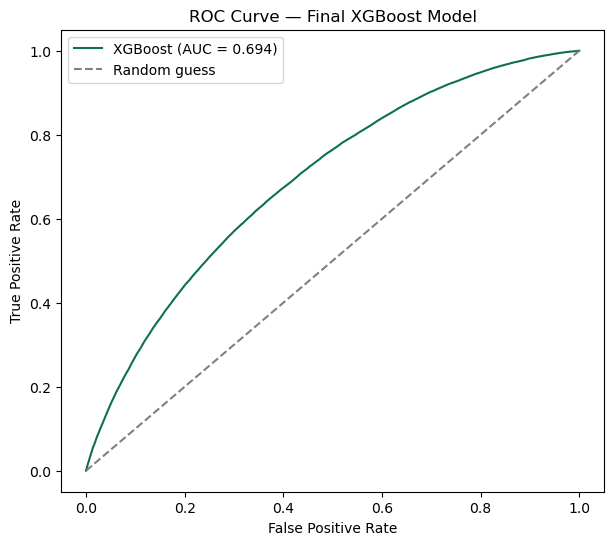

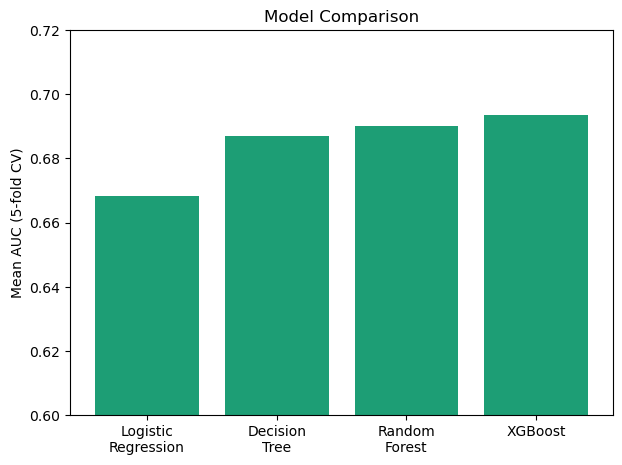

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import os

os.makedirs('../figures', exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, pd_test)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {xgb_scores.mean():.3f})', color='#0F6E56')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final XGBoost Model'); plt.legend()
plt.savefig('../figures/roc_curve.png', dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost']
aucs = [log_scores.mean(), dt_scores.mean(), rf_scores.mean(), xgb_scores.mean()]
plt.bar(names, aucs, color='#1D9E75')
plt.ylabel('Mean AUC (5-fold CV)'); plt.title('Model Comparison'); plt.ylim(0.6, 0.72)
plt.savefig('../figures/model_comparison.png', dpi=150)
plt.show()